In [193]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import re
import os
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go

In [194]:
# loading the csv file and converting to csv
df = pd.read_csv("UK-Sanctions-List.csv",skiprows = 1, low_memory = False)
df.shape
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in this dataset.")

There are 57033 rows and 58 columns in this dataset.


In [195]:
#Data types in the dataset
df.dtypes

Last Updated                                   object
Unique ID                                      object
OFSI Group ID                                 float64
UN Reference Number                            object
Name 6                                         object
Name 1                                         object
Name 2                                         object
Name 3                                         object
Name 4                                         object
Name 5                                         object
Name type                                      object
Alias strength                                 object
Title                                          object
Name non-latin script                          object
Non-latin script type                          object
Non-latin script language                      object
Regime Name                                    object
Designation Type                               object
Designation source          

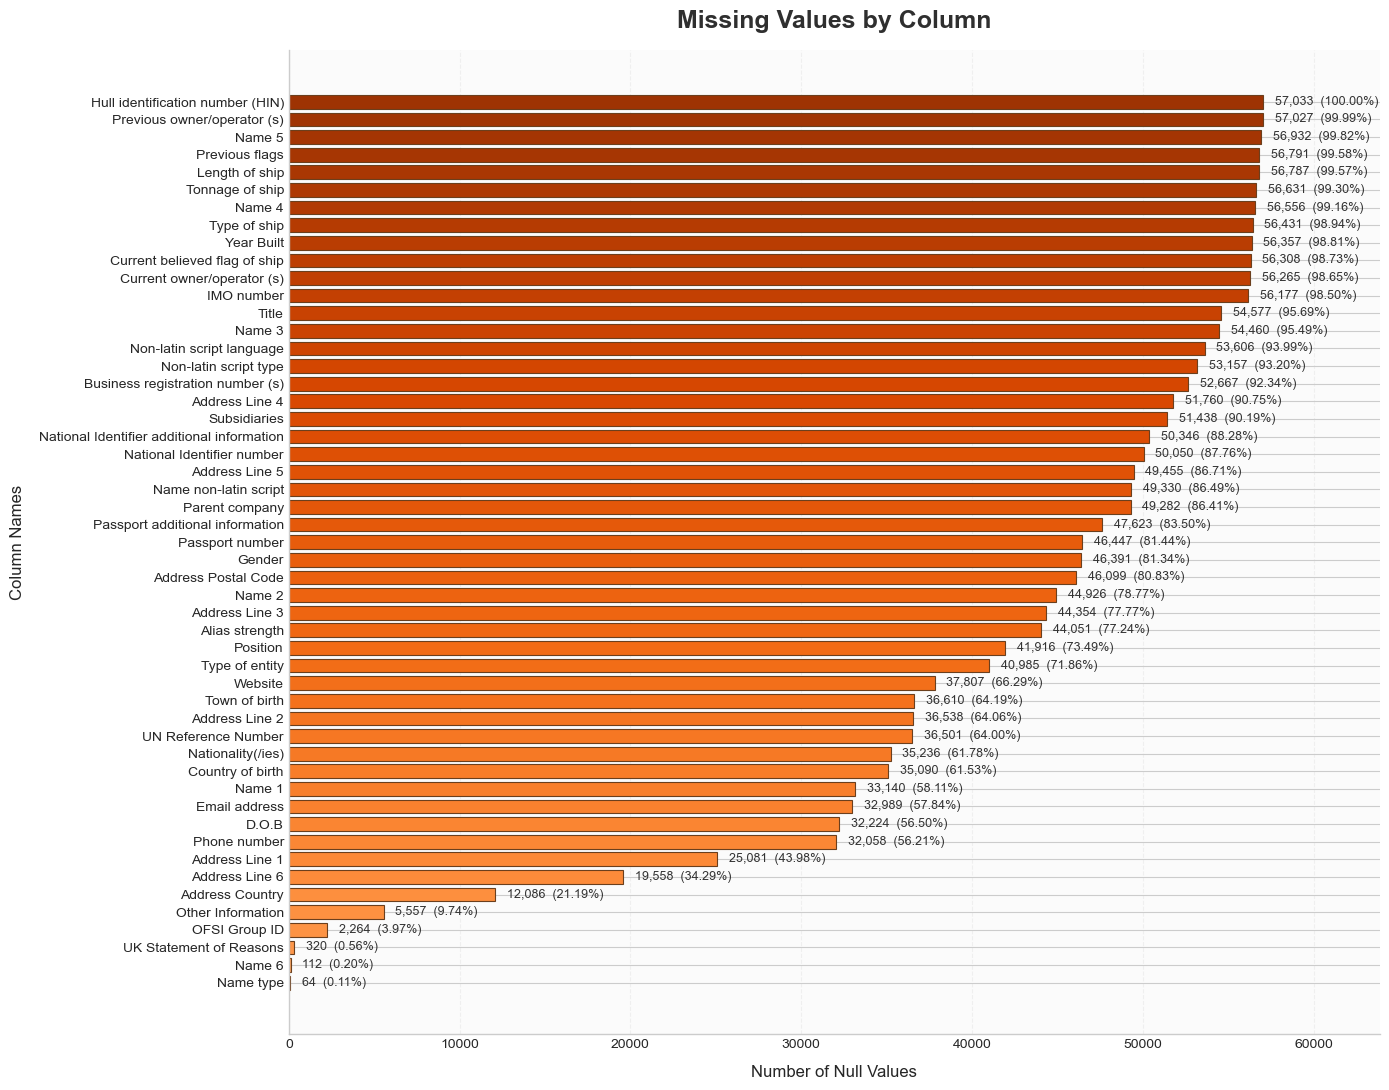

In [196]:
# calculating for null values

null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

report = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_pct
})


report = report[report['Null Count'] > 0].sort_values('Null Count', ascending=True)

# Clean visual style for the chart
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')
ax.set_facecolor('#fbfbfb')

colors = plt.cm.Oranges(np.linspace(0.45, 0.9, len(report)))
bars = ax.barh(
    report.index,
    report['Null Count'],
    color=colors,
    edgecolor='#6b3f1d',
    linewidth=0.8,
    height=0.78
)


max_nulls = report['Null Count'].max()
for bar, pct in zip(bars, report['Null %']):
    width = bar.get_width()
    ax.text(
        width + max_nulls * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}  ({pct:.2f}%)',
        ha='left',
        va='center',
        fontsize=9,
        color='#333333',
        fontweight='medium'
    )

ax.set_title(
    'Missing Values by Column',
    fontsize=18,
    fontweight='bold',
    pad=16,
    color='#2f2f2f'
)
ax.set_xlabel('Number of Null Values', fontsize=12, labelpad=10)
ax.set_ylabel('Column Names', fontsize=12, labelpad=10)


ax.set_xlim(0, max_nulls * 1.12)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [197]:
# report on duplication and unique values
report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Total Rows': len(df),
    'Unique Values': df.nunique(),
    'Missing Values': df.isnull().sum(),
    'Duplicate Rate %': ((len(df) - df.nunique()) / len(df) * 100).round(2)
})

report.sort_values('Unique Values', ascending=False)

,Data Type,Total Rows,Unique Values,Missing Values,Duplicate Rate %
Name 6,object,57033,11174,112,80.41
Unique ID,object,57033,6046,0,89.40
OFSI Group ID,float64,57033,5137,2264,90.99
UK Statement of Reasons,object,57033,4049,320,92.90
Name non-latin script,object,57033,3586,49330,93.71
Name 1,object,57033,2664,33140,95.33
D.O.B,object,57033,2648,32224,95.36
Position,object,57033,2255,41916,96.05
Name 2,object,57033,1793,44926,96.86
Address Line 1,object,57033,1569,25081,97.25


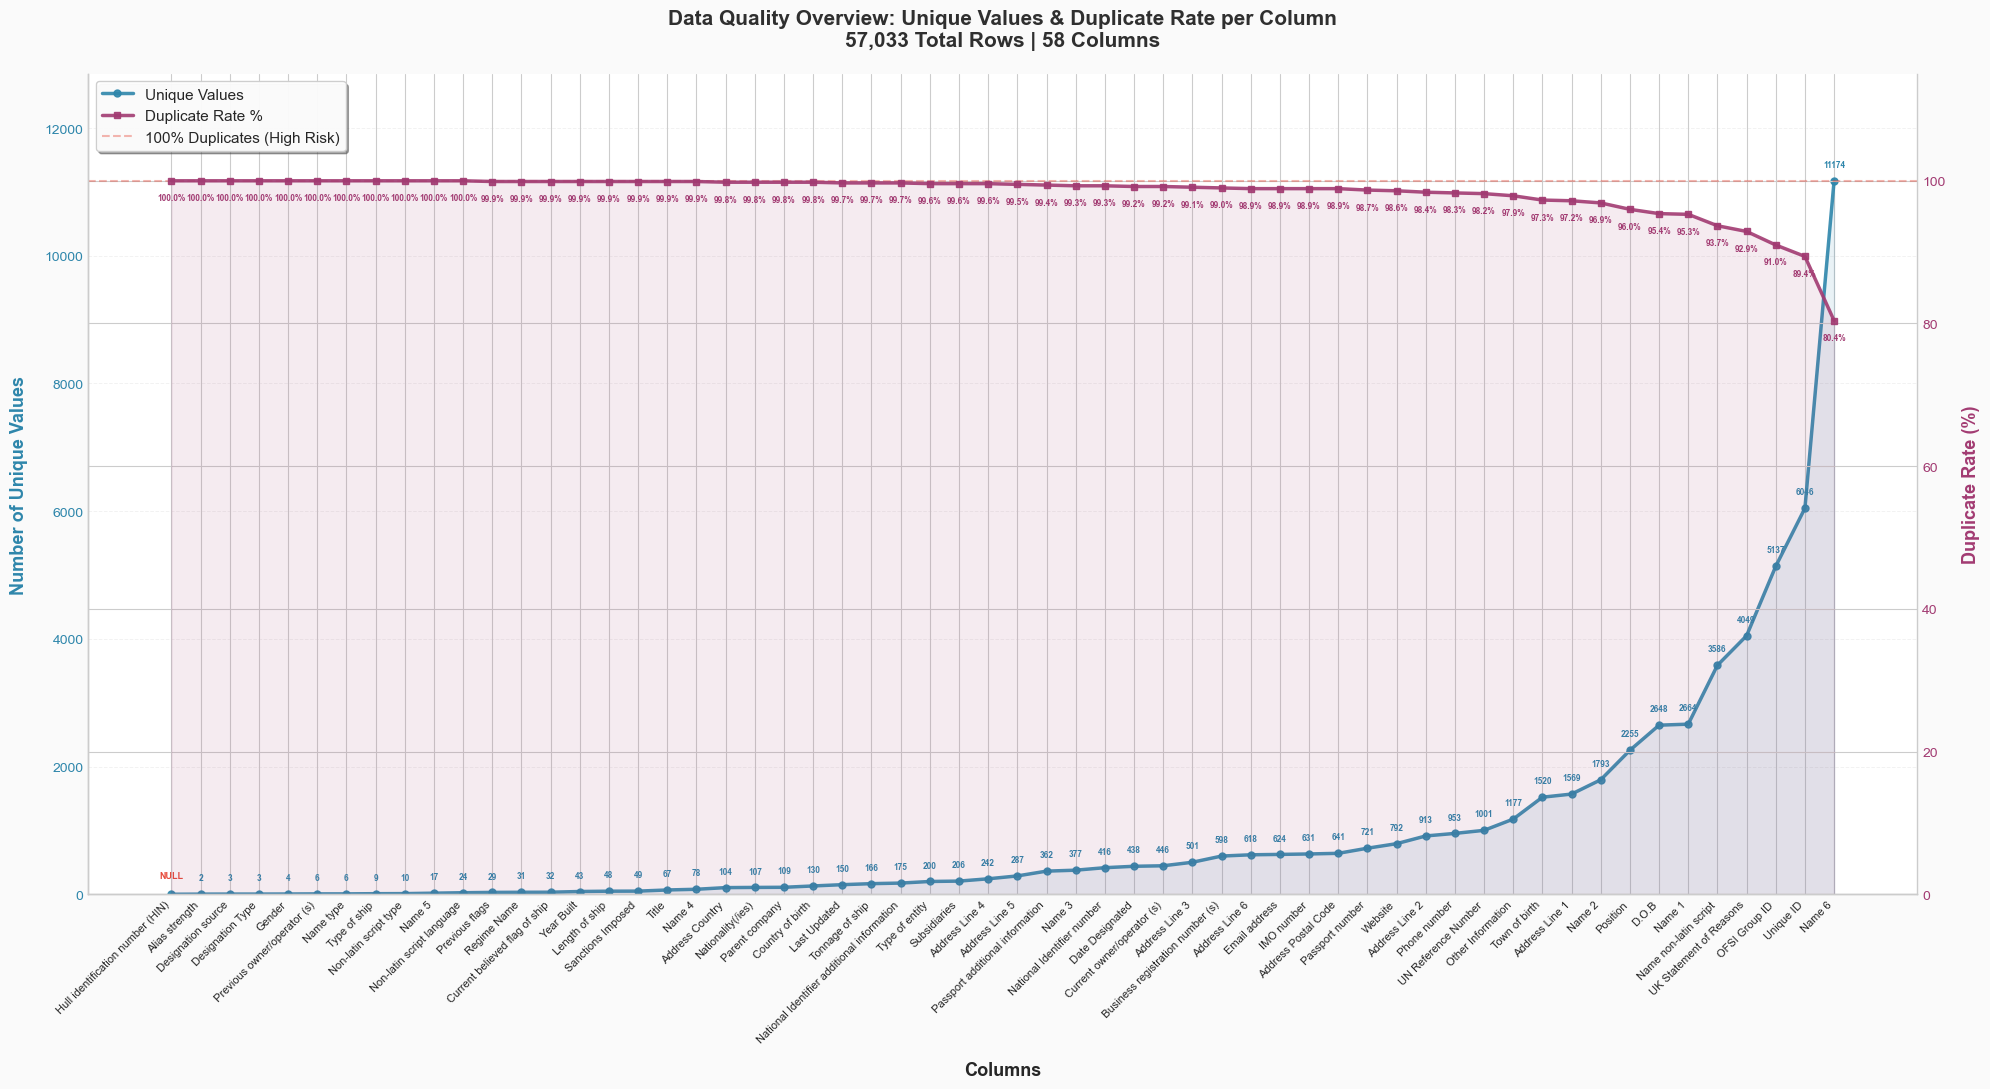

In [198]:
# 
# Build the report
report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Total Rows': len(df),
    'Unique Values': df.nunique(),
    'Missing Values': df.isnull().sum(),
    'Duplicate Rate %': ((len(df) - df.nunique()) / len(df) * 100).round(1)
})

report = report.sort_values('Unique Values', ascending=True)

fig, ax1 = plt.subplots(figsize=(20, 11), facecolor='#fafafa')
ax1.set_facecolor('#ffffff')

x = range(len(report))
columns = report.index

color1 = '#2E86AB'  
line1 = ax1.plot(x, report['Unique Values'], color=color1, marker='o', linewidth=2.5, 
                  markersize=5, label='Unique Values', zorder=4, alpha=0.9)
# Add area under the line
ax1.fill_between(x, 0, report['Unique Values'], color=color1, alpha=0.1, zorder=2)

ax1.set_xlabel('Columns', fontsize=13, fontweight='bold', labelpad=12)
ax1.set_ylabel('Number of Unique Values', color=color1, fontsize=13, fontweight='bold', labelpad=12)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=10)
ax1.set_ylim(0, max(report['Unique Values']) * 1.15)

label_step = max(1, len(report) // 35)  
for i, val in enumerate(report['Unique Values']):
    if val == 0:
        ax1.annotate('NULL', (i, val), textcoords="offset points", xytext=(0, 12),
                    ha='center', fontsize=6.5, color='#e74c3c', fontweight='bold', zorder=5)
    elif i % label_step == 0 or val == report['Unique Values'].max():  
        ax1.annotate(f'{int(val)}', (i, val), textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=6, color=color1, fontweight='bold', zorder=5)

ax2 = ax1.twinx()
color2 = '#A23B72' 
line2 = ax2.plot(x, report['Duplicate Rate %'], color=color2, marker='s', linewidth=2.5, 
                  markersize=5, label='Duplicate Rate %', zorder=4, alpha=0.9)

ax2.fill_between(x, 0, report['Duplicate Rate %'], color=color2, alpha=0.1, zorder=2)

ax2.set_ylabel('Duplicate Rate (%)', color=color2, fontsize=13, fontweight='bold', labelpad=12)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)
ax2.set_ylim(0, 115)


ax2.axhline(y=100, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.4, 
            label='100% Duplicates (High Risk)', zorder=1)


for i, val in enumerate(report['Duplicate Rate %']):
    if i % label_step == 0 or val == report['Duplicate Rate %'].max():
        ax2.annotate(f'{val}%', (i, val), textcoords="offset points", xytext=(0, -14),
                    ha='center', fontsize=6, color=color2, fontweight='bold', zorder=5)

ax1.set_xticks(x)
label_interval = max(1, len(report) // 30) 
x_labels = [columns[i] if i % label_interval == 0 else '' for i in range(len(columns))]
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)


plt.title(f'Data Quality Overview: Unique Values & Duplicate Rate per Column\n{len(df):,} Total Rows | {len(df.columns)} Columns', 
          fontsize=15, fontweight='bold', pad=20, color='#2f2f2f')

ax1.grid(True, alpha=0.25, axis='y', linestyle='--', linewidth=0.7, color='#cccccc')
ax1.set_axisbelow(True)

lines = line1 + line2 + [ax2.get_lines()[-1]]  # reference line
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11, frameon=True, 
          fancybox=True, shadow=True, framealpha=0.95)

# improving visibility
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [199]:
df['Gender'].value_counts()

Gender
Male      9764
Female     845
male        25
female       8
Name: count, dtype: int64

In [200]:
df['Name type'].value_counts()

Name type
Alias                     34303
Primary name               7244
Primary Name Variation     6153
Primary Name               6034
Primary name variation     3233
ALias                         2
Name: count, dtype: int64

In [201]:
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 20: 
        print(f"Column: {col} | Unique values: {n_unique}")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"\n{col}: {n_unique} unique values — skipped")
        


Last Updated: 150 unique values — skipped

Unique ID: 6046 unique values — skipped

OFSI Group ID: 5137 unique values — skipped

UN Reference Number: 1001 unique values — skipped

Name 6: 11174 unique values — skipped

Name 1: 2664 unique values — skipped

Name 2: 1793 unique values — skipped

Name 3: 377 unique values — skipped

Name 4: 78 unique values — skipped
Column: Name 5 | Unique values: 17
Name 5
NaN                   56932
Mira                     36
Muhammad                 18
Hassan                    8
MARDAN                    8
Ahmad                     6
MUHAMMAD                  4
al-Tayib                  4
Othman                    4
das Neves                 2
Aissa Hamed Dawoud        2
HALIM                     2
Mabrouk                   2
Namr                      1
BAFUNKWA                  1
Jammeh                    1
Said ould                 1
Allah                     1
Name: count, dtype: int64
Column: Name type | Unique values: 6
Name type
Alias        

In [202]:
df_copy = df.copy()
print(f"The shape of the copy {df_copy.shape}.")
print(f"The shape of the original {df.shape}.")

The shape of the copy (57033, 58).
The shape of the original (57033, 58).


In [203]:
'Hull identification number (HIN)' in df_copy.columns

True

In [204]:
# Droping Hull identification number (HIN) column as it is empty.
df_copy.drop('Hull identification number (HIN)', axis=1, inplace=True)
df_copy.head()

,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Business registration number (s),IMO number,Current owner/operator (s),Previous owner/operator (s),Current believed flag of ship,Previous flags,Type of ship,Tonnage of ship,Length of ship,Year Built
0,16/04/2026,AFG0001,12703.0,TAe.010,HAJI KHAIRULLAH HAJI SATTAR MONEY EXCHANGE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16/04/2026,AFG0001,12703.0,TAe.010,HAJI KHAIRULLAH HAJI SATTAR MONEY EXCHANGE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,16/04/2026,AFG0001,12703.0,TAe.010,HAJI KHAIRULLAH HAJI SATTAR MONEY EXCHANGE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,16/04/2026,AFG0001,12703.0,TAe.010,HAJI KHAIRULLAH HAJI SATTAR MONEY EXCHANGE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,16/04/2026,AFG0001,12703.0,TAe.010,HAJI KHAIRULLAH HAJI SATTAR MONEY EXCHANGE,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [205]:
'Hull identification number (HIN)' in df_copy.columns

False

In [206]:
# make a copy of the df and converting most of the text based columns to Title case for better visibility and tracking.

# striping and title casing.
text_cols = ['Name 6','Name 1','Name 2','Name 3','Name 4','Name 5','Name type','Gender','Type of ship']

for col in text_cols:
    df_copy[col] = df_copy[col].str.strip().str.title()

In [207]:
df_copy.tail(20)

,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Business registration number (s),IMO number,Current owner/operator (s),Previous owner/operator (s),Current believed flag of ship,Previous flags,Type of ship,Tonnage of ship,Length of ship,Year Built
57013,14/06/2022,YEM0010,NaN,NaN,Partisans Of God,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57014,14/06/2022,YEM0010,NaN,NaN,Supporters Of God,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57015,17/08/2023,YEM0011,15591.0,NaN,Al-Marrani,Motlaq,Amer,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57016,13/01/2023,YEM0012,15595.0,NaN,Al-Hamzi,Ahmad,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57017,13/01/2023,YEM0012,15595.0,NaN,Al-Hamzi,Ahmad'Ali,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57018,13/01/2023,YEM0012,15595.0,NaN,Al-Hamzi,Ahmad'Ali,Ahsan,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57019,13/01/2023,YEM0012,15595.0,NaN,Al-Hamzi,Ahmed,Ali,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57020,13/01/2023,YEM0012,15595.0,NaN,Al-Hamzi,Muti,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57021,17/08/2023,YEM0013,15592.0,NaN,Al-Sa'Adi,Mansur,Ahmad,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57022,09/04/2025,YEM0014,16346.0,NaN,Al-Atifi,Mohamed,Nasser,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [208]:
df['Name 6'].value_counts()

Name 6
Adam                        972
Kony                        730
Taghtiran P.J.S Kashan      588
Taghtiran Kashan Company    588
Taghtiran Kashan Co.        588
                           ... 
ALIMOVA                       1
AKSYONENKO                    1
AITKULOVA                     1
ABAKAROV                      1
Al-Huthi                      1
Name: count, Length: 11174, dtype: int64

In [209]:
df_copy['Name 6'].value_counts()

Name 6
Adam                      1213
Kony                       980
Taghtiran P.J.S Kashan     588
Taghtiran                  588
Taghtiran Co.              588
                          ... 
Moussavi                     1
Taghipour                    1
Hamlbar                      1
Bozorgnia                    1
Abdulnabi                    1
Name: count, Length: 10680, dtype: int64

We can see that the visibility and tracking numbers are up for adam and kony from 972 and 730 to 1212 and 980 respectively.

In [210]:
df['Gender'].value_counts()

Gender
Male      9764
Female     845
male        25
female       8
Name: count, dtype: int64

In [211]:
df_copy['Gender'].value_counts()


Gender
Male      9789
Female     853
Name: count, dtype: int64

After addition of Male and male cols and Female and female cols, the data is consistant. The same goes for Name 6.

In [212]:
df['Type of ship'].value_counts()

Type of ship
Oil Tanker                       384
General Cargo / Multi Purpose     94
Oil tanker                        67
Chemical/Products Tanker          19
Chemical Carrier                  14
LNG Tanker                        13
Bulk Carrier                       6
Other                              3
Ro-Ro Cargo                        2
Name: count, dtype: int64

In [213]:
df_copy['Type of ship'].value_counts()

Type of ship
Oil Tanker                       451
General Cargo / Multi Purpose     94
Chemical/Products Tanker          19
Chemical Carrier                  14
Lng Tanker                        13
Bulk Carrier                       6
Other                              3
Ro-Ro Cargo                        2
Name: count, dtype: int64

In [214]:
df['Name 6'].value_counts()

Name 6
Adam                        972
Kony                        730
Taghtiran P.J.S Kashan      588
Taghtiran Kashan Company    588
Taghtiran Kashan Co.        588
                           ... 
ALIMOVA                       1
AKSYONENKO                    1
AITKULOVA                     1
ABAKAROV                      1
Al-Huthi                      1
Name: count, Length: 11174, dtype: int64

In [215]:
df_copy['Name 6'].value_counts()

Name 6
Adam                      1213
Kony                       980
Taghtiran P.J.S Kashan     588
Taghtiran                  588
Taghtiran Co.              588
                          ... 
Moussavi                     1
Taghipour                    1
Hamlbar                      1
Bozorgnia                    1
Abdulnabi                    1
Name: count, Length: 10680, dtype: int64

In [216]:
# combining name columns into a single column.
name_cols = [f'Name {i}' for i in range(1, 7)]
df_copy['name_combined'] = (
    df_copy[name_cols]
    .fillna('')
    .astype(str)
    .apply(lambda row: ' '.join(part.strip() for part in row if part.strip()), axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df_copy[['name_combined'] + name_cols].tail(20)

,name_combined,Name 1,Name 2,Name 3,Name 4,Name 5,Name 6
57013,Partisans Of God,NaN,NaN,NaN,NaN,NaN,Partisans Of God
57014,Supporters Of God,NaN,NaN,NaN,NaN,NaN,Supporters Of God
57015,Motlaq Amer Al-Marrani,Motlaq,Amer,NaN,NaN,NaN,Al-Marrani
57016,Ahmad Al-Hamzi,Ahmad,NaN,NaN,NaN,NaN,Al-Hamzi
57017,Ahmad'Ali Al-Hamzi,Ahmad'Ali,NaN,NaN,NaN,NaN,Al-Hamzi
57018,Ahmad'Ali Ahsan Al-Hamzi,Ahmad'Ali,Ahsan,NaN,NaN,NaN,Al-Hamzi
57019,Ahmed Ali Al-Hamzi,Ahmed,Ali,NaN,NaN,NaN,Al-Hamzi
57020,Muti Al-Hamzi,Muti,NaN,NaN,NaN,NaN,Al-Hamzi
57021,Mansur Ahmad Al-Sa'Adi,Mansur,Ahmad,NaN,NaN,NaN,Al-Sa'Adi
57022,Mohamed Nasser Al-Atifi,Mohamed,Nasser,NaN,NaN,NaN,Al-Atifi


In [217]:
'name_combined' in df_copy.columns


True

In [218]:
df_copy['Phone number'].value_counts()

Phone number
+ 98 21 22988006      1260
+98 21 2298 8007      1260
+98 21 2254 9664      1260
+90 216 3646945        584
+98 21 8798978         560
                      ... 
'009821-88643750         1
8 (800) 551-00-15        1
+7 85557 59001           1
+7(495) 720 49 499       1
+963-11-5111352          1
Name: count, Length: 953, dtype: int64

In [219]:
def clean_phone(phone):
    if pd.isna(phone):
        return pd.NA
    
    phone = str(phone).lstrip("'").strip()
    
    # remove  minus
    if phone.startswith('-'):
        phone = phone[1:]
    
    # remove all non-digit characters
    digits = re.sub(r'\D', '', phone)
    
    # If empty after cleaning, return NaN
    if len(digits) == 0:
        return pd.NA
    
    # Keep + for international numbers
    if phone.startswith('+'):
        return '+' + digits
    
    # Otherwise return cleaned digits
    return digits

# instead of inplace we create new column so that we can track back.
df_copy['Phone_Clean'] = df_copy['Phone number'].apply(clean_phone)

df_copy['Phone_Clean'].value_counts()

Phone_Clean
+982122988007     1260
+982122988006     1260
+982122549664     1260
+902163646945      584
+98218798978       560
                  ... 
+8613825722727       1
84951085157          1
+73432870287         1
+74957847700         1
+963115111352        1
Name: count, Length: 939, dtype: int64

In [220]:
df_copy['D.O.B'].value_counts().head(50)

D.O.B
26/12/1955    1011
dd/mm/1967     555
01/01/1967     501
dd/mm/1970     472
dd/mm/1969     432
dd/mm/1971     392
dd/mm/1961     389
dd/mm/1959     363
dd/mm/1962     307
dd/mm/1964     302
dd/mm/1960     292
01/01/1971     289
01/01/1970     288
dd/mm/1963     283
dd/mm/1968     271
dd/mm/1965     240
28/09/1973     236
03/03/1965     216
22/08/1973     211
10/06/1982     210
26/09/1973     210
31/12/1979     210
26/08/1973     210
01/01/1964     201
dd/mm/1975     196
dd/mm/1977     175
dd/mm/1951     173
dd/mm/1976     172
05/10/1965     168
dd/mm/1966     163
16/12/1987     162
dd/mm/1957     161
04/12/1960     144
12/04/1960     144
01/01/1962     144
dd/mm/1973     143
dd/mm/1958     127
dd/mm/1972     126
01/01/1961     125
dd/08/1961     124
dd/07/1961     120
dd/04/1963     120
18/09/1964     120
01/01/1972     116
dd/mm/1954     113
dd/mm/1978     105
dd/mm/1956     102
dd/mm/1953      99
22/02/1986      96
dd/mm/1955      95
Name: count, dtype: int64

In [221]:
def parse_dob(dob):
    if pd.isna(dob):
        return pd.NaT
    
    dob = str(dob).strip()
    
    # d/m values cannot be empty so keeping them as 01/01/yyyy.
    if dob.startswith('dd/mm/'):
        year = dob.split('/')[-1]
        return pd.to_datetime(f'01/01/{year}', format='%d/%m/%Y')
    
    return pd.to_datetime(dob, format='%d/%m/%Y', errors='coerce')

df_copy['D.O.B_Clean'] = df_copy['D.O.B'].apply(parse_dob)

# Verify
print(df_copy[['D.O.B', 'D.O.B_Clean']].tail(20))

            D.O.B D.O.B_Clean
57013         NaN         NaT
57014         NaN         NaT
57015  01/01/1984  1984-01-01
57016        1985         NaT
57017        1985         NaT
57018        1985         NaT
57019        1985         NaT
57020        1985         NaT
57021        1988         NaT
57022  dd/mm/1969  1969-01-01
57023  dd/mm/1969  1969-01-01
57024         NaN         NaT
57025         NaN         NaT
57026         NaN         NaT
57027         NaN         NaT
57028         NaN         NaT
57029         NaN         NaT
57030         NaN         NaT
57031         NaN         NaT
57032         NaN         NaT


In [222]:
#parse the last updated columns to datetime
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'], dayfirst=True, errors='coerce')
print(df_copy['Last Updated'].head(20))

0    2026-04-16
1    2026-04-16
2    2026-04-16
3    2026-04-16
4    2026-04-16
5    2026-04-16
6    2026-04-16
7    2026-04-16
8    2026-04-16
9    2026-04-16
10   2026-04-16
11   2026-04-16
12   2026-04-16
13   2026-04-16
14   2026-04-16
15   2026-04-16
16   2026-04-16
17   2026-04-16
18   2026-04-16
19   2026-04-16
Name: Last Updated, dtype: datetime64[ns]


In [223]:
df_copy['Date Designated'] = pd.to_datetime(df_copy['Date Designated'], dayfirst=True, errors='coerce')
print(df_copy['Date Designated'].head(20))

0    2012-06-29
1    2012-06-29
2    2012-06-29
3    2012-06-29
4    2012-06-29
5    2012-06-29
6    2012-06-29
7    2012-06-29
8    2012-06-29
9    2012-06-29
10   2012-06-29
11   2012-06-29
12   2012-06-29
13   2012-06-29
14   2012-06-29
15   2012-06-29
16   2012-06-29
17   2012-06-29
18   2012-06-29
19   2012-06-29
Name: Date Designated, dtype: datetime64[ns]


In [224]:
df_copy['OFSI Group ID'] = df_copy['OFSI Group ID'].fillna('').astype(str)

df_copy['OFSI Group ID'].head()

0    12703.0
1    12703.0
2    12703.0
3    12703.0
4    12703.0
Name: OFSI Group ID, dtype: object

In [225]:
df_copy['OFSI Group ID'] = (
    df_copy['OFSI Group ID'].fillna('').astype(str).str.replace('.0', '', regex=False)
)

print(df_copy['OFSI Group ID'].head())

0    12703
1    12703
2    12703
3    12703
4    12703
Name: OFSI Group ID, dtype: object


In [226]:
# trim whitespace from address columns
address_cols_to_trim = ['Address Line 1', 'Address Line 2', 'Address Line 3', 
                        'Address Line 4', 'Address Line 5', 'Address Line 6',
                        'Address Postal Code', 'Address Country']

for col in address_cols_to_trim:
    df_copy[col] = df_copy[col].str.strip()

#combining address into one column for easier matching and also keeping the address columns to cross check in the future.
df_copy['Full_Address'] = df_copy[address_cols_to_trim].apply(
    lambda x: ', '.join(x.dropna().astype(str)), axis=1
)
df_copy['Full_Address'] = df_copy['Full_Address'].str.replace('nan', '', regex=False).str.strip(', ')

print(df_copy['Full_Address'].head(10))

0                        Branch Office 16, Zabul, Iran
1    Ansari Market, 2nd Floor, Nimroz Province, Afg...
2    Branch Office 8, Gereshk City, Nahr-e Saraj Di...
3    New Sarafi Market, 2nd Floor, Kandahar City, K...
4    Branch Office 6, Shop number 237, Shah Zada Ma...
5    Branch Office 10, Suite numbers 196-197, 3rd F...
6    Branch Office 9, Lashkar Gah Bazaar, Lashkar G...
7    Safi Market, Kandahar City, Kandahar Province,...
8    Branch Office 7, Shop numbers 21 and 22, 2nd F...
9    Branch Office 11, Sarafi Market, Zaranj Distri...
Name: Full_Address, dtype: object


In [227]:
df_copy['Full_Address'].head(10)

0                        Branch Office 16, Zabul, Iran
1    Ansari Market, 2nd Floor, Nimroz Province, Afg...
2    Branch Office 8, Gereshk City, Nahr-e Saraj Di...
3    New Sarafi Market, 2nd Floor, Kandahar City, K...
4    Branch Office 6, Shop number 237, Shah Zada Ma...
5    Branch Office 10, Suite numbers 196-197, 3rd F...
6    Branch Office 9, Lashkar Gah Bazaar, Lashkar G...
7    Safi Market, Kandahar City, Kandahar Province,...
8    Branch Office 7, Shop numbers 21 and 22, 2nd F...
9    Branch Office 11, Sarafi Market, Zaranj Distri...
Name: Full_Address, dtype: object

In [228]:
df_copy['Nationality(/ies)'].value_counts(dropna=False).head(20)

Nationality(/ies)
NaN                            35236
Afghanistan                     2501
Russia                          2279
Syria                           1526
Algeria                         1491
Central African Republic        1454
South Sudan                     1099
India                           1023
Iraq                             910
Ukraine                          680
Belarus                          621
Chad                             616
Libya                            477
Indonesia                        473
Iran                             422
Sudan                            418
Uganda                           380
Congo (Democratic Republic)      379
Tunisia                          372
Philippines                      349
Name: count, dtype: int64

In [229]:
# Check for multiple nationalities in a single row
# First, let's see all nationality columns
nationality_cols = [col for col in df_copy.columns if 'Nationality' in col]
print(f"Nationality columns found: {nationality_cols}\n")

# Show sample data
print("Sample rows with nationality data:")
print(df_copy[nationality_cols].head(20))

# Check how many rows have multiple nationalities
multi_nationality = df_copy[nationality_cols].notna().sum(axis=1)
print(f"\n\nDistribution of number of nationalities per row:")
print(multi_nationality.value_counts().sort_index())

# Show rows with multiple nationalities
print(f"\n\nRows with multiple nationalities:")
multi_nat_rows = df_copy[multi_nationality > 1]
print(f"Total rows with multiple nationalities: {len(multi_nat_rows)}")
if len(multi_nat_rows) > 0:
    print("\nSample:")
    print(multi_nat_rows[nationality_cols].head(10))

Nationality columns found: ['Nationality(/ies)']

Sample rows with nationality data:
   Nationality(/ies)
0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
5                NaN
6                NaN
7                NaN
8                NaN
9                NaN
10               NaN
11               NaN
12               NaN
13               NaN
14               NaN
15               NaN
16               NaN
17               NaN
18               NaN
19               NaN


Distribution of number of nationalities per row:
0    35236
1    21797
Name: count, dtype: int64


Rows with multiple nationalities:
Total rows with multiple nationalities: 0


No Multinationality

In [230]:
# Check if individual nationality cells contain multiple values (separated by delimiters)
nat_col = 'Nationality(/ies)'
print(df_copy[nat_col].value_counts(dropna=False))

Nationality(/ies)
NaN            35236
Afghanistan     2501
Russia          2279
Syria           1526
Algeria         1491
               ...  
Slovakia           1
Kazakhstan         1
Honduras           1
Kyrgyzstan         1
New Zealand        1
Name: count, Length: 108, dtype: int64


In [231]:
df_copy['National Identifier number'].value_counts().head(20)

National Identifier number
20227088368           1440
103-00653129-22        896
20645897               630
A0680623               240
'010868617             162
13080011550             84
5877002                 84
54201-247561-5          84
2135314355              72
202112421               72
2181558                 72
3219222002.2181558      72
 660603-05-5267         72
5420250161699           60
585629                  60
631605846798            60
11010046398             57
1729765                 56
2020409266              54
2020316097              54
Name: count, dtype: int64

In [232]:
def clean_identifier(identifier):
    if pd.isna(identifier):
        return pd.NA
    
    identifier = str(identifier).strip()
    # Remove leading quotes/apostrophes
    identifier = identifier.lstrip("'\"")
    
    return identifier if identifier else pd.NA

# Apply the function
df_copy['National Identifier number_Clean'] = df_copy['National Identifier number'].apply(clean_identifier)

In [233]:
df_copy['National Identifier number_Clean'].value_counts().head(20)

National Identifier number_Clean
20227088368           1440
103-00653129-22        896
20645897               630
A0680623               240
010868617              162
13080011550             84
5877002                 84
54201-247561-5          84
2135314355              72
202112421               72
2181558                 72
3219222002.2181558      72
660603-05-5267          72
5420250161699           60
585629                  60
631605846798            60
11010046398             57
1729765                 56
2020409266              54
2020316097              54
Name: count, dtype: int64

In [234]:
df_copy['Sanctions Imposed'].value_counts(dropna=False)

Sanctions Imposed
Asset freeze|Director Disqualification Sanction                                                                                                                                                                                   20101
Asset freeze|Travel Ban                                                                                                                                                                                                            8756
Asset freeze|Arms embargo|Travel Ban                                                                                                                                                                                               7389
Asset freeze|Travel Ban|Director Disqualification Sanction                                                                                                                                                                         5853
Asset freeze|Trust Services Sanctions|Director Disqual

In [235]:
# Split on | and count entries per row
df_copy['Sanctions_Count'] = df_copy['Sanctions Imposed'].apply(
    lambda x: len(str(x).split('|')) if pd.notna(x) else 0
)

# See the maximum
max_sanctions = df_copy['Sanctions_Count'].max()
print(f"Maximum number of sanctions per entry: {max_sanctions}")

# See the distribution
print(df_copy['Sanctions_Count'].value_counts().sort_index())

Maximum number of sanctions per entry: 7
Sanctions_Count
1     3195
2    30910
3    16846
4     4019
5      883
6     1069
7      111
Name: count, dtype: int64


In [236]:
# Show rows with maximum sanctions
df_copy[df_copy['Sanctions_Count'] == max_sanctions][['Unique ID', 'Name 1', 'Sanctions Imposed', 'Sanctions_Count']].head(10)


,Unique ID,Name 1,Sanctions Imposed,Sanctions_Count
44209,RUS0235,Gennadiy,Asset freeze|Travel Ban|Technical assistance r...,7
44210,RUS0235,Gennadiy,Asset freeze|Travel Ban|Technical assistance r...,7
44211,RUS0235,Gennadiy,Asset freeze|Travel Ban|Technical assistance r...,7
44212,RUS0235,Gennadi,Asset freeze|Travel Ban|Technical assistance r...,7
44213,RUS0235,Gennadi,Asset freeze|Travel Ban|Technical assistance r...,7
44214,RUS0235,Gennadi,Asset freeze|Travel Ban|Technical assistance r...,7
44215,RUS0235,Gennady,Asset freeze|Travel Ban|Technical assistance r...,7
44216,RUS0235,Gennady,Asset freeze|Travel Ban|Technical assistance r...,7
44217,RUS0235,Gennady,Asset freeze|Travel Ban|Technical assistance r...,7
44360,RUS0267,Andrei,Asset freeze|Travel Ban|Technical assistance r...,7


In [237]:
# Split and explode to get individual sanctions
all_sanctions = df_copy['Sanctions Imposed'].dropna().str.split('|').explode().str.strip()

# Clean counts
print(all_sanctions.value_counts())

Sanctions Imposed
Asset freeze                                                                  56232
Director Disqualification Sanction                                            34612
Travel Ban                                                                    25989
Arms embargo                                                                   9173
Trust Services Sanctions                                                       8358
Transport sanctions: see 'Other information'                                   1467
Prohibition of port entry                                                      1180
Prevention of business arrangements                                             961
Chartering of Ships                                                             960
Shipping sanctions: (see 'Other information')                                   945
Crew servicing of ships and aircraft                                            773
Closure of representative offices                         

In [238]:
print(f"Total rows: {len(df_copy)}")
print(f"Rows with sanctions: {df_copy['Sanctions Imposed'].notna().sum()}")
print(f"Max sanctions per row: {df_copy['Sanctions_Count'].max()}")
print(f"Most common sanction: {all_sanctions.value_counts().index[0]}")

Total rows: 57033
Rows with sanctions: 57033
Max sanctions per row: 7
Most common sanction: Asset freeze


In [239]:
# Create 7 columns for sanctions
for i in range(7):
    df_copy[f'Sanction_{i+1}'] = df_copy['Sanctions Imposed'].apply(
        lambda x: str(x).split('|')[i].strip() if pd.notna(x) and i < len(str(x).split('|')) else pd.NA
    )

# Verify
print(df_copy[['Sanctions Imposed', 'Sanction_1', 'Sanction_2', 'Sanction_3', 'Sanction_4', 
               'Sanction_5', 'Sanction_6', 'Sanction_7']].tail(10))


                                       Sanctions Imposed    Sanction_1  \
57023  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57024  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57025  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57026  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57027  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57028  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57029  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57030  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57031  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   
57032  Asset freeze|Targeted arms embargo|Travel Ban|...  Asset freeze   

                  Sanction_2  Sanction_3                          Sanction_4  \
57023  Targeted arms embargo  Travel Ban  Director Disqualification Sanction   
57024  Targeted arms emba

In [240]:
# Check for different separators
for sep in [',', '/', ';', ' | ', ' & ',' and ', '|','and']:
    count = df_copy['Nationality(/ies)'].str.contains(sep, na=False).sum()
    if count > 0:
        print(f"'{sep}' found in {count} rows")

' | ' found in 3974 rows
' and ' found in 152 rows
'|' found in 21797 rows
'and' found in 713 rows


In [241]:
df['Nationality(/ies)'].value_counts()

Nationality(/ies)
Afghanistan                 2501
Russia                      2279
Syria                       1526
Algeria                     1491
Central African Republic    1454
                            ... 
Slovakia                       1
Kazakhstan                     1
Honduras                       1
Kyrgyzstan                     1
New Zealand                    1
Name: count, Length: 107, dtype: int64

In [242]:
# Check for different separators
for sep in [',', '/', ';', ' | ', ' & ', ' and ', '|', 'and']:
    count = df_copy['Nationality(/ies)'].str.contains(sep, na=False).sum()
    if count > 0:
        print(f"\n{'='*60}")
        print(f"'{sep}' found in {count} rows")
        print(f"{'='*60}")
        
        # Show examples
        mask = df_copy['Nationality(/ies)'].str.contains(sep, na=False)
        examples = df_copy[mask]['Nationality(/ies)'].unique()[:10]
        
        for ex in examples:
            print(f"  • {ex}")


' | ' found in 3974 rows
  • Saudi Arabia
  • United States
  • United Kingdom
  • Bosnia and Herzegovina
  • Trinidad and Tobago
  • Central African Republic
  • South Sudan
  • North Korea
  • Congo (Democratic Republic)
  • South Africa

' and ' found in 152 rows
  • Bosnia and Herzegovina
  • Trinidad and Tobago
  • St Kitts and Nevis

'|' found in 21797 rows
  • Afghanistan
  • Pakistan
  • Qatar
  • Kuwait
  • Iraq
  • Libya
  • Egypt
  • Mauritania
  • Yemen
  • Algeria

'and' found in 713 rows
  • Bosnia and Herzegovina
  • Trinidad and Tobago
  • Uganda
  • Ireland
  • Netherlands
  • Rwanda
  • Thailand
  • St Kitts and Nevis
  • Finland
  • Switzerland


In [243]:
df_copy['Passport number'].value_counts()

Passport number
D00001184    720
P04838205    720
D00000897    448
D00004262    448
3987189      168
            ... 
637008563      1
511834383      1
752050900      1
756186942      1
383862880      1
Name: count, Length: 721, dtype: int64

In [244]:
# Parse passport additional information into structured columns
passport_col = 'Passport additional information'

if passport_col in df_copy.columns:
    def parse_passport_info(text):
        result = {
            'Passport_Issuing_Country': pd.NA,
            'Passport_Issue_Date': pd.NaT,
            'Passport_Expiry_Date': pd.NaT,
            'Passport_Issuing_City': pd.NA,
        }

        if pd.isna(text):
            return result

        text = re.sub(r'\s+', ' ', str(text)).strip()

        # Issuing country: first words before "passport"
        match = re.search(r'^([A-Za-z ]+?)\s+passport', text, re.I)
        if match:
            result['Passport_Issuing_Country'] = match.group(1).strip().title()

        # Issue date: "issued on <date>"
        match = re.search(r'issued on\s+([\d]{1,2}\s+\w+\s+\d{4})', text, re.I)
        if match:
            result['Passport_Issue_Date'] = pd.to_datetime(match.group(1), errors='coerce', dayfirst=True)

        # Expiry date: "expires <date>"
        match = re.search(r'expires?\s+([\d]{1,2}\s+\w+\s+\d{4})', text, re.I)
        if match:
            result['Passport_Expiry_Date'] = pd.to_datetime(match.group(1), errors='coerce', dayfirst=True)

        # Issuing city: "issued in <City>"
        match = re.search(r'issued in\s+([A-Za-z ]+?)(?:,|$)', text, re.I)
        if match:
            result['Passport_Issuing_City'] = match.group(1).strip().title()

        return result

    passport_parsed = df_copy[passport_col].apply(parse_passport_info)
    passport_df = pd.DataFrame(passport_parsed.tolist())

    for col in passport_df.columns:
        df_copy[col] = passport_df[col].values

    print('Passport additional info parsed:')
    display_cols = [
        'Passport additional information',
        'Passport_Issuing_Country',
        'Passport_Issue_Date',
        'Passport_Expiry_Date',
        'Passport_Issuing_City',
    ]
    print(df_copy[display_cols].dropna(subset=['Passport_Issuing_Country']).head(5))
else:
    print(f"Column not found: {passport_col}")


Passport additional info parsed:
                        Passport additional information  \
1021  Afghanistan passport number P04581926, issued ...   
1022  Afghanistan passport number P04581926, issued ...   
1023  Afghanistan passport number P04581926, issued ...   
1024  Afghanistan passport number P04581926, issued ...   
1025  Afghanistan passport number P04581926, issued ...   

     Passport_Issuing_Country Passport_Issue_Date Passport_Expiry_Date  \
1021              Afghanistan          2024-08-07           2034-08-07   
1022              Afghanistan          2024-08-07           2034-08-07   
1023              Afghanistan          2024-08-07           2034-08-07   
1024              Afghanistan          2024-08-07           2034-08-07   
1025              Afghanistan          2024-08-07           2034-08-07   

     Passport_Issuing_City  
1021              Kandahar  
1022              Kandahar  
1023              Kandahar  
1024              Kandahar  
1025              Kand

In [245]:
df_copy['Subsidiaries'].value_counts()

Subsidiaries
Iran Electronics Industries Co (Saga)                                                        420
The Institute of Isayran Co                                                                  420
Telecommunication Industries of Iran (SAMA)                                                  420
Shiraz Electronics Industries (Sara Shiraz)                                                  420
Security Industry Information Space (SASTOBA)                                                420
                                                                                            ... 
Zheng Heng (Cambodia) Co., Ltd                                                                 1
1. Sokan Arvand Ship Management Company 2. Persia Telecom Co. 3. Nilsun Kish 4. IOEC E&P       1
BIC Bank                                                                                       1
Cargo Link Petroleum Logistics Company Limited                                                 1
Petrostroi-SPB Ak

In [246]:
df_copy['Subsidiaries'] = df_copy['Subsidiaries'].str.strip()

In [247]:
df_copy['Subsidiaries'].value_counts()

Subsidiaries
Iran Electronics Industries Co (Saga)                                                       420
The Institute of Isayran Co                                                                 420
Telecommunication Industries of Iran (SAMA)                                                 420
Shiraz Electronics Industries (Sara Shiraz)                                                 420
Security Industry Information Space (SASTOBA)                                               420
                                                                                           ... 
Zheng Heng (Cambodia) Co., Ltd                                                                1
1. Sokan Arvand Ship Management Company 2. Persia Telecom Co. 3. Nilsun Kish 4. IOEC E&P      1
BIC Bank                                                                                      1
Cargo Link Petroleum Logistics Company Limited                                                1
Petrostroi-SPB Aktsionernoe

In [248]:
# Create a new column counting subsidiaries per entry
df_copy['Subsidiary_Count'] = df_copy['Subsidiaries'].apply(
    lambda x: len([s for s in str(x).split(' ') if s.isdigit() and s != '0']) 
    if pd.notna(x) else 0
)

df_copy[['Subsidiaries', 'Subsidiary_Count']].value_counts()

Subsidiaries                                                                                                                                                                                    Subsidiary_Count
Security Industry Information Space (SASTOBA)                                                                                                                                                   0                   420
Iran Electronics Industries Co (Saga)                                                                                                                                                           0                   420
The Institute of Isayran Co                                                                                                                                                                     0                   420
Telecommunication Industries of Iran (SAMA)                                                                                                    

In [249]:
# Build the parsed subsidiaries columns on demand so this cell works even after a kernel reset
if 'Subsidiary_Count_Parsed' not in df_copy.columns:
    def split_subsidiary_entries(value):
        if pd.isna(value):
            return []

        text = re.sub(r'\s+', ' ', str(value)).strip()
        if not text:
            return []

        parts = re.split(r'\s*(?:\||;|/|\n)\s*', text)
        entries = []

        for part in parts:
            matches = re.findall(r'.+?\s-\s\d+(?=[A-Z]|$)', part)
            if matches:
                entries.extend(match.strip(' ,') for match in matches)
            else:
                entries.append(part.strip(' ,'))

        return [entry for entry in entries if entry]

    df_copy['Subsidiaries_List'] = df_copy['Subsidiaries'].apply(split_subsidiary_entries)
    df_copy['Subsidiary_Count_Parsed'] = df_copy['Subsidiaries_List'].str.len()


df_copy['Has_Multiple_Subs'] = df_copy['Subsidiary_Count_Parsed'] > 1

df_copy.loc[
    df_copy['Has_Multiple_Subs'],
    ['Subsidiaries', 'Subsidiaries_List', 'Subsidiary_Count_Parsed']
].head(10)

,Subsidiaries,Subsidiaries_List,Subsidiary_Count_Parsed
22408,Myawaddy Trading Ltd; Myawaddy Travels and Tou...,"[Myawaddy Trading Ltd, Myawaddy Travels and To...",2
22425,Inndagaw Industrial Complex; Kanpauk Oil Palm ...,"[Inndagaw Industrial Complex, Kanpauk Oil Palm...",2
22431,Lann Pyi Marine Company Ltd; Larbathakedi Micr...,"[Lann Pyi Marine Company Ltd, Larbathakedi Mic...",2
22452,Lann Pyi Marine Company Ltd; Larbathakedi Micr...,"[Lann Pyi Marine Company Ltd, Larbathakedi Mic...",2
22458,Inndagaw Industrial Complex; Kanpauk Oil Palm ...,"[Inndagaw Industrial Complex, Kanpauk Oil Palm...",2
22461,Myawaddy Trading Ltd; Myawaddy Travels and Tou...,"[Myawaddy Trading Ltd, Myawaddy Travels and To...",2
22485,Myawaddy Trading Ltd; Myawaddy Travels and Tou...,"[Myawaddy Trading Ltd, Myawaddy Travels and To...",2
22500,Inndagaw Industrial Complex; Kanpauk Oil Palm ...,"[Inndagaw Industrial Complex, Kanpauk Oil Palm...",2
22506,Lann Pyi Marine Company Ltd; Larbathakedi Micr...,"[Lann Pyi Marine Company Ltd, Larbathakedi Mic...",2
22515,"Agro Pack Co., Ltd.; Aung Myint Mo Min Securities","[Agro Pack Co., Ltd., Aung Myint Mo Min Securi...",2


In [250]:
df_copy['Sub_Type'] = df_copy['Subsidiaries'].apply(
    lambda x: 'Bank' if 'bank' in str(x).lower() 
              else 'Telecom' if 'telecom' in str(x).lower()
              else 'Electronics' if 'electronics' in str(x).lower()
              else 'Other' if pd.notna(x) else 'Missing'
)

df_copy['Subsidiaries'] = df_copy['Subsidiaries'].str.replace(
    r'(Co\.?|Ltd\.?|Inc\.?)\s*$', '', regex=True
).str.strip()

In [251]:
# Parse subsidiaries into separate entries so concatenated values become usable records
def split_subsidiary_entries(value):
    if pd.isna(value):
        return []

    text = re.sub(r'\s+', ' ', str(value)).strip()
    if not text:
        return []

    # First split on explicit separators when they exist.
    parts = re.split(r'\s*(?:\||;|/|\n)\s*', text)
    entries = []

    # Then split concatenated patterns like:
    # Company One - 123Company Two - 456
    for part in parts:
        matches = re.findall(r'.+?\s-\s\d+(?=[A-Z]|$)', part)
        if matches:
            entries.extend(match.strip(' ,') for match in matches)
        else:
            entries.append(part.strip(' ,'))

    return [entry for entry in entries if entry]


df_copy['Subsidiaries_List'] = df_copy['Subsidiaries'].apply(split_subsidiary_entries)
df_copy['Subsidiary_Count_Parsed'] = df_copy['Subsidiaries_List'].str.len()

In [252]:
df_copy['Designation Type'].value_counts()

Designation Type
Entity        29762
Individual    26414
Ship            857
Name: count, dtype: int64

In [253]:

# Filter for Designation Type == 'Shipl'
ship_records = df_copy[df_copy['Designation Type'] == 'Ship']

print(f"Total ship records: {len(ship_records)}")


Total ship records: 857


In [254]:
# do this in df_unique
# Filter for Designation Type == 'Entity'
entity_df = df_copy[df_copy['Designation Type'] == 'Entity'].copy()

print(f"Total Entity records: {len(entity_df)}")
print(f"Unique Companies (by Unique ID): {entity_df['Unique ID'].nunique()}")

# Group by Unique ID (company identifier) and get company info and sanction count
company_sanctions = entity_df.groupby('Unique ID').agg({
    'Name 6': 'first',  # Get the first/main company name
    'Sanctions_Count': 'sum',  # Total sanctions for the company
    'Unique ID': 'count'  # Number of records for this company
}).reset_index(drop=True)

company_sanctions.columns = ['Company_Name', 'Total_Sanctions', 'Record_Count']
company_sanctions = company_sanctions.sort_values('Total_Sanctions', ascending=False)

print(f"\nCompanies with their total sanctions:")
print(company_sanctions.head(30))

print(f"Total unique companies: {len(company_sanctions)}")


Total Entity records: 29762
Unique Companies (by Unique ID): 1531

Companies with their total sanctions:
                                           Company_Name  Total_Sanctions  \
352                         Iran Electronics Industries             7560   
391                                           Taghtiran             7056   
388               Step Standart Teknik Parca San Ve Tic             5600   
323                     Sharif University Of Technology             3840   
226    Korea Ryonha Machinery Joint Venture Corporation             3024   
1511                    Mechanical Construction Factory             2288   
348         Iran Aircraft Manufacturing Company (Iamco)             2160   
12                                      Al Rashid Trust             1694   
366                            Macpar Makina San Ve Tic             1584   
139                                    Blood And Honour             1292   
374                                      Parto Sanat Co    

In [255]:
# Count distinct names per Unique ID
names_per_id = df_copy.groupby('Unique ID')['Name 6'].nunique().reset_index()
names_per_id.columns = ['Unique_ID', 'Distinct_Names_Count']
names_per_id = names_per_id.sort_values('Distinct_Names_Count', ascending=False)

print(f"Total Unique IDs: {len(names_per_id)}")
print(f"\nDistribution of distinct names per Unique ID:")
print(names_per_id['Distinct_Names_Count'].value_counts().sort_index())

print(f"\nTop 20 Unique IDs with most different names:")
print(names_per_id.head(20))

# Show details for IDs with multiple names
multi_name_ids = names_per_id[names_per_id['Distinct_Names_Count'] > 1]
print(f"\nUnique IDs with more than 1 name: {len(multi_name_ids)}")

# Show example: Unique ID with all its different names
if len(multi_name_ids) > 0:
    sample_id = multi_name_ids.iloc[0]['Unique_ID']
    print(f"\nExample - Unique ID {sample_id} with different names:")
    sample_names = df_copy[df_copy['Unique ID'] == sample_id][['Unique ID', 'Name 6', 'Designation Type']].drop_duplicates()
    print(sample_names)

# Save to CSV
multi_name_ids.to_csv(r"C:\Stuff\testNotebook'\output\ids_with_multiple_names.csv", index=False)
print(f"\n✓ Saved to output folder")

Total Unique IDs: 6046

Distribution of distinct names per Unique ID:
Distinct_Names_Count
0        2
1     3779
2     1023
3      471
4      283
5      167
6       98
7       64
8       50
9       37
10      20
11      15
12      14
13       5
14       3
15       4
16       3
17       2
18       3
19       1
20       1
27       1
Name: count, dtype: int64

Top 20 Unique IDs with most different names:
     Unique_ID  Distinct_Names_Count
199    AQD0065                    27
1617   INU0118                    20
720    CTD0006                    19
1729   INU0323                    18
288    AQD0159                    18
5560   SOM0001                    18
5859   SYR0252                    17
1751   INU0347                    17
452    AQD0344                    16
163    AQD0028                    16
256    AQD0125                    16
235    AQD0103                    15
1602   INU0099                    15
436    AQD0325                    15
956    DPR0093                    15
316

In [256]:
df_copy['Subsidiaries'].value_counts()

Subsidiaries
Iran Electronics Industries Co (Saga)                                                       420
The Institute of Isayran                                                                    420
Telecommunication Industries of Iran (SAMA)                                                 420
Shiraz Electronics Industries (Sara Shiraz)                                                 420
Security Industry Information Space (SASTOBA)                                               420
                                                                                           ... 
Zheng Heng (Cambodia) Co.,                                                                    1
1. Sokan Arvand Ship Management Company 2. Persia Telecom Co. 3. Nilsun Kish 4. IOEC E&P      1
BIC Bank                                                                                      1
Cargo Link Petroleum Logistics Company Limited                                                1
Petrostroi-SPB Aktsionernoe

In [257]:
df_copy['Subsidiary_Count_Parsed'].value_counts()

Subsidiary_Count_Parsed
0    51438
1     5005
2      445
3       64
4       50
6       29
5        2
Name: count, dtype: int64

In [258]:
df_copy['Subsidiaries_List'].value_counts()

Subsidiaries_List
[]                                                                                            51438
[Telecommunication Industries of Iran (SAMA)]                                                   420
[AIS Iran]                                                                                      420
[Electronic Component Industries (ECI)]                                                         420
[Iranian Electronic Science & Research Institute]                                               420
                                                                                              ...  
[Cargo Link Petroleum Logistics Company Limited]                                                  1
[1. Sokan Arvand Ship Management Company 2. Persia Telecom Co. 3. Nilsun Kish 4. IOEC E&P]        1
[BIC Bank]                                                                                        1
[Zheng Heng (Cambodia) Co.]                                                       

In [259]:
df_copy['Designation source'].value_counts()   

Designation source
UK       36216
UN       20450
UK|UN      367
Name: count, dtype: int64

In [260]:

df_copy['designation_list'] = df_copy['Designation source'].str.split('|')

df_copy['designation_number'] = df_copy['designation_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)

df_copy['designation_one'] = df_copy['Designation source'].str.split('|').str[0]
df_copy['designation_two'] = df_copy['Designation source'].str.split('|').str[1]

df_copy[['designation_one', 'designation_two']] = df_copy[['designation_one', 'designation_two']].fillna('')

df_copy = df_copy.drop('designation_list', axis=1)

print(df_copy[['Designation source', 'designation_number', 'designation_one', 'designation_two']].head(10))

  Designation source  designation_number designation_one designation_two
0                 UN                   1              UN                
1                 UN                   1              UN                
2                 UN                   1              UN                
3                 UN                   1              UN                
4                 UN                   1              UN                
5                 UN                   1              UN                
6                 UN                   1              UN                
7                 UN                   1              UN                
8                 UN                   1              UN                
9                 UN                   1              UN                


In [261]:
df_copy['designation_number'].value_counts()

designation_number
1    56666
2      367
Name: count, dtype: int64

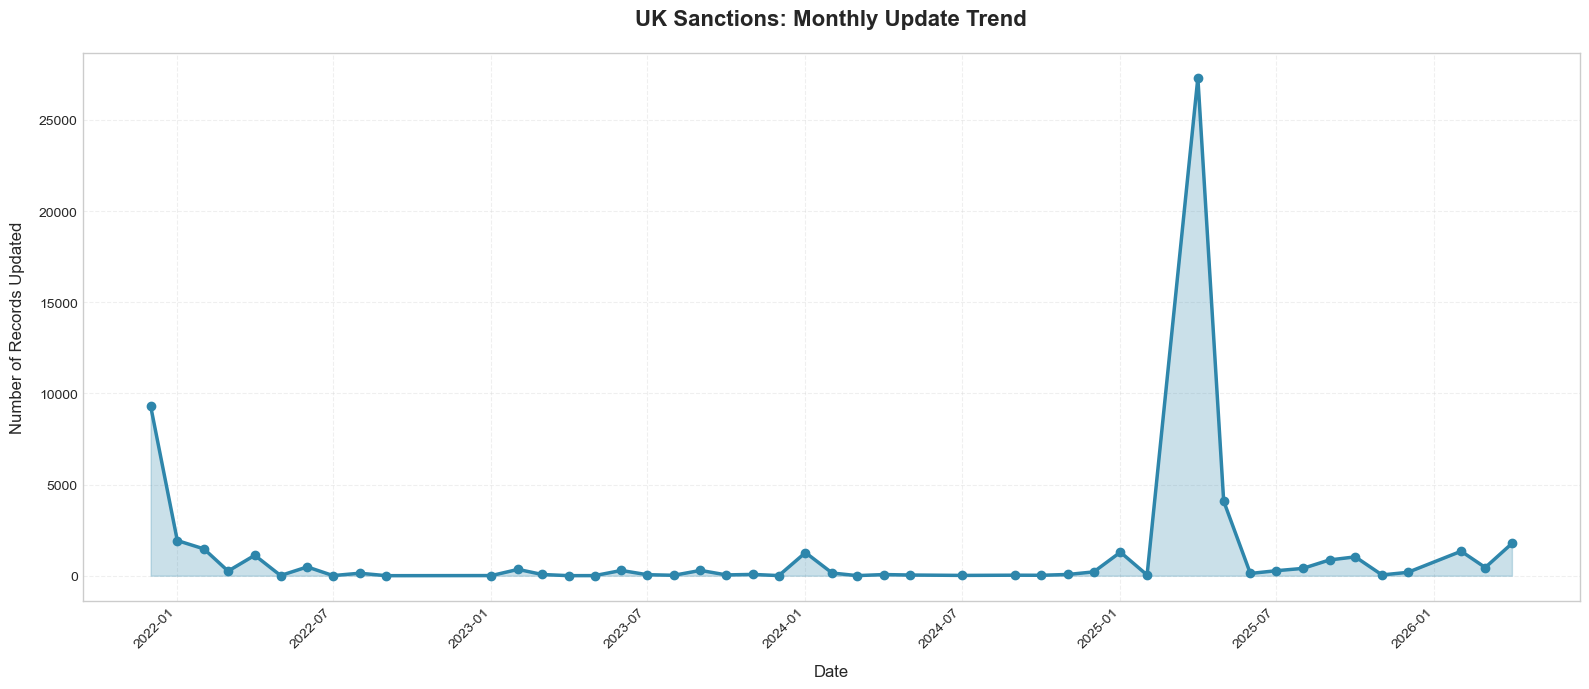

Date range: 2021-12-18 to 2026-04-29
Average updates per month: 1240


In [262]:
# Visualize Last Updated trends by month
# Aggregate by month for cleaner visualization
df_copy['Last Updated Month'] = df_copy['Last Updated'].dt.to_period('M')

# Count records per month
monthly_updates = df_copy.groupby('Last Updated Month').size().reset_index(name='Count')
monthly_updates['Last Updated Month'] = monthly_updates['Last Updated Month'].dt.to_timestamp()

# Create line chart
plt.figure(figsize=(16, 7))
plt.plot(monthly_updates['Last Updated Month'], monthly_updates['Count'], 
         color='#2E86AB', linewidth=2.5, marker='o', markersize=6, label='Monthly Updates')

# Fill area under curve
plt.fill_between(monthly_updates['Last Updated Month'], monthly_updates['Count'], 
                 alpha=0.25, color='#2E86AB')

plt.title('UK Sanctions: Monthly Update Trend', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Number of Records Updated', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# Add some statistics to the plot
max_month = monthly_updates.loc[monthly_updates['Count'].idxmax()]
plt.tight_layout()
plt.show()

print(f"Date range: {df_copy['Last Updated'].min().date()} to {df_copy['Last Updated'].max().date()}")
print(f"Average updates per month: {monthly_updates['Count'].mean():.0f}")


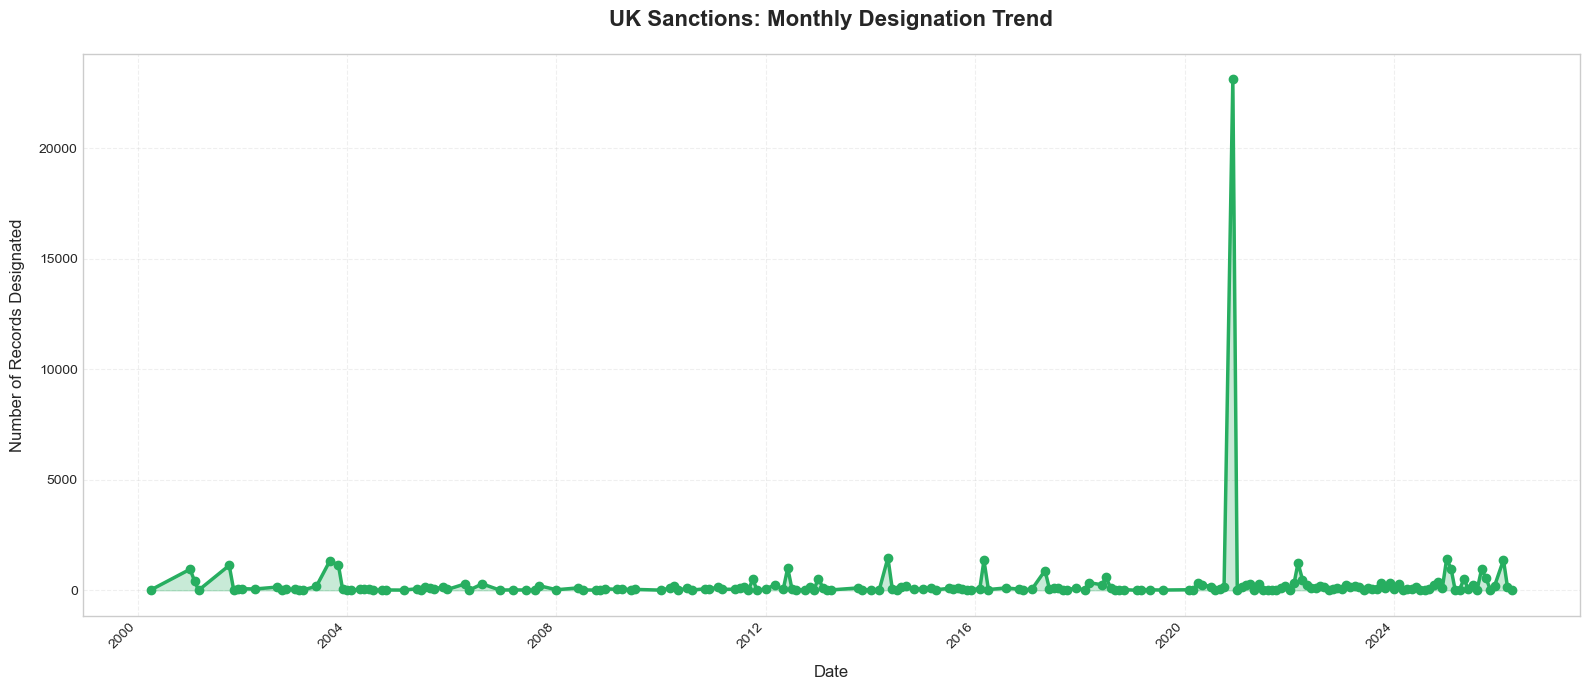

Date range: 2000-04-12 to 2026-04-28
Months covered: 199
Average designations per month: 287
Peak month: December 2020 (23121 records)


In [263]:
# Visualize Date Designated trends by month
# Aggregate by month for cleaner visualization
df_copy['Date Designated Month'] = df_copy['Date Designated'].dt.to_period('M')

# Count records per month
monthly_designated = df_copy.groupby('Date Designated Month').size().reset_index(name='Count')
monthly_designated['Date Designated Month'] = monthly_designated['Date Designated Month'].dt.to_timestamp()

# Create line chart
plt.figure(figsize=(16, 7))
plt.plot(monthly_designated['Date Designated Month'], monthly_designated['Count'], 
         color='#27AE60', linewidth=2.5, marker='o', markersize=6, label='Monthly Designations')

# Fill area under curve
plt.fill_between(monthly_designated['Date Designated Month'], monthly_designated['Count'], 
                 alpha=0.25, color='#27AE60')

plt.title('UK Sanctions: Monthly Designation Trend', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Number of Records Designated', fontsize=12, labelpad=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# Add peak annotation
max_month = monthly_designated.loc[monthly_designated['Count'].idxmax()]

plt.tight_layout()
plt.show()

print(f"Date range: {df_copy['Date Designated'].min().date()} to {df_copy['Date Designated'].max().date()}")
print(f"Months covered: {len(monthly_designated)}")
print(f"Average designations per month: {monthly_designated['Count'].mean():.0f}")
print(f"Peak month: {max_month['Date Designated Month'].strftime('%B %Y')} ({max_month['Count']:.0f} records)")

In [264]:
df_copy['D.O.B_Clean'].value_counts().sort_index()

D.O.B_Clean
1923-01-01    2
1924-01-01    1
1925-01-25    2
1925-03-13    2
1929-01-21    1
             ..
2001-09-03    1
2002-05-07    1
2002-05-19    4
2002-09-12    3
2002-12-13    1
Name: count, Length: 2565, dtype: int64

In [265]:
# Extract age in whole years from the cleaned date of birth column
reference_date = pd.Timestamp.today().normalize()

df_copy['age_extracted'] = (
    (reference_date - df_copy['D.O.B_Clean']).dt.days.div(365.25).floordiv(1)
    .astype('Int64')
)



In [266]:
df_copy['age_extracted'].value_counts()

age_extracted
59     1431
52     1363
70     1290
56     1225
65     1053
       ... 
103       2
95        2
25        2
102       1
97        1
Name: count, Length: 78, dtype: Int64

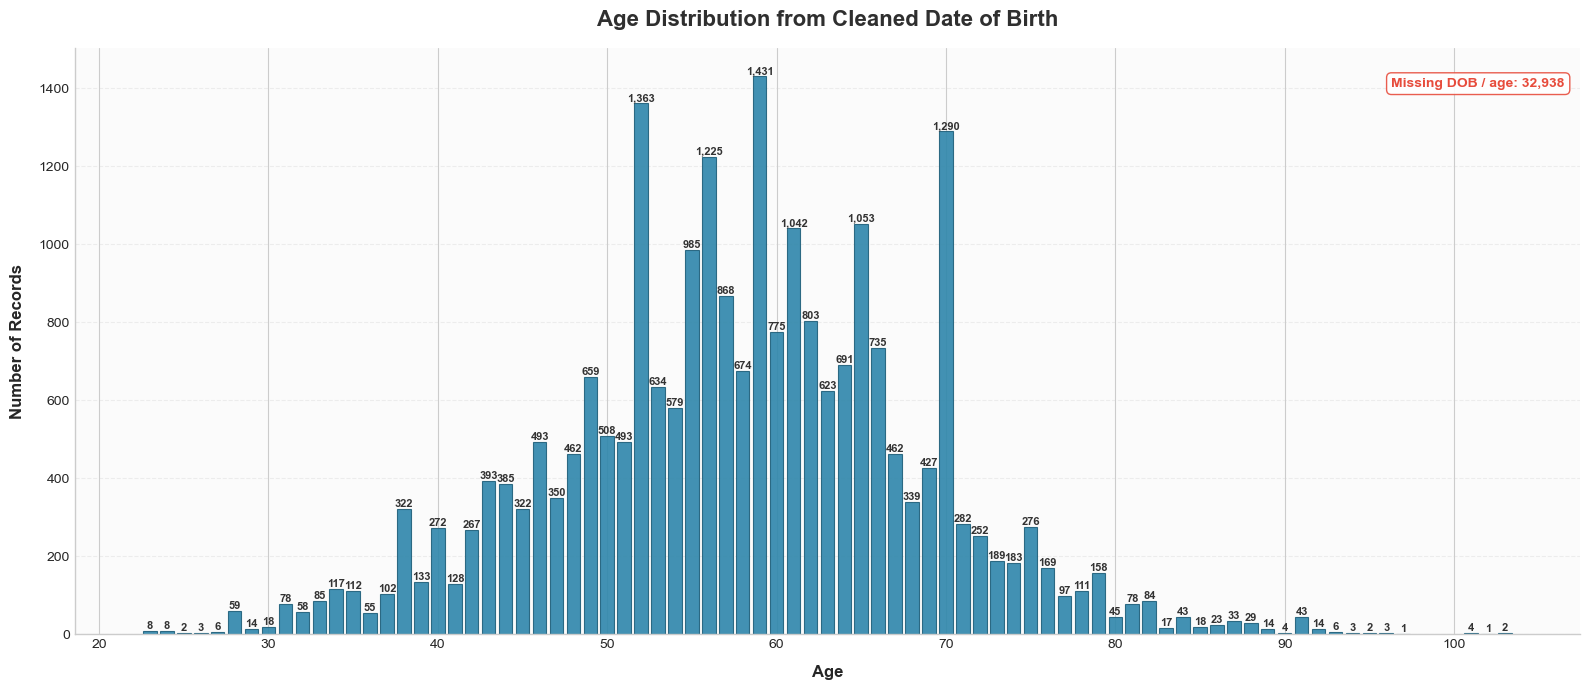

In [267]:
# Plot the age distribution
age_counts = df_copy['age_extracted'].value_counts(dropna=False).sort_index()

# Separate valid ages from missing values for cleaner plotting
valid_age_counts = age_counts[age_counts.index.notna()]
missing_age_count = int(age_counts.get(pd.NA, 0)) if pd.NA in age_counts.index else 0

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 7), facecolor='white')
ax.set_facecolor('#fbfbfb')

bars = ax.bar(
    valid_age_counts.index.astype(int),
    valid_age_counts.values,
    color='#2E86AB',
    edgecolor='#1f5f7a',
    linewidth=0.8,
    alpha=0.9,
    width=0.8
)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=8,
            color='#333333',
            fontweight='bold'
        )

ax.set_title('Age Distribution from Cleaned Date of Birth', fontsize=16, fontweight='bold', pad=16, color='#2f2f2f')
ax.set_xlabel('Age', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Number of Records', fontsize=12, fontweight='bold', labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Optional note for missing values
if missing_age_count > 0:
    ax.text(
        0.99,
        0.95,
        f'Missing DOB / age: {missing_age_count:,}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        color='#e74c3c',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#e74c3c', alpha=0.9)
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()


In [268]:
df['Position'].value_counts()

Position
Commander of the Lord’s Resistance Army                                                                     1200
General                                                                                                      481
Director General of the Extraordinary Committee for the Defence of Democratic Achievements                   480
Minister for Security                                                                                        480
President                                                                                                    448
                                                                                                            ... 
Former Head of the Administrative Justice Court                                                                1
Member of the Management Committee                                                                             1
Vice-chairman of the judiciary administration of South Khorasan province, in charge of 

In [269]:
# Make a hashable version of the dataframe before calling duplicated()
df_hashable = df_copy.copy()

for col in df_hashable.columns:
    df_hashable[col] = df_hashable[col].apply(
        lambda x: tuple(x) if isinstance(x, list) else x
    )

duplicate_count = df_hashable.duplicated().sum()
print(f"Exact sanction matches (all columns identical): {duplicate_count}")

Exact sanction matches (all columns identical): 659


In [270]:
# Make a hashable copy to check for exact duplicates
df_dup_check = df_copy.copy()

def make_hashable(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, dict):
        return tuple(sorted(value.items()))
    if isinstance(value, set):
        return tuple(sorted(value))
    return value

for col in df_dup_check.columns:
    if df_dup_check[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
        df_dup_check[col] = df_dup_check[col].apply(make_hashable)

# Count exact duplicates (all columns identical)
exact_duplicate_count = df_dup_check.duplicated().sum()
print(f"Total exact duplicate rows: {exact_duplicate_count}")

# Get all duplicated rows (including first occurrence)
all_duplicates = df_dup_check[df_dup_check.duplicated(keep=False)]
print(f"Total rows involved in duplication groups: {len(all_duplicates)}")

# Group duplicates by their duplicate set
duplicate_groups = all_duplicates.groupby(list(df_dup_check.columns), dropna=False).size().reset_index(name='Count')
duplicate_groups = duplicate_groups[duplicate_groups['Count'] > 1].sort_values('Count', ascending=False)

print(f"\nNumber of unique duplicate sets: {len(duplicate_groups)}")
print("\nTop 10 duplicate groups (by frequency):")
print(duplicate_groups[['Count']].head(10))

# Example: Show the first duplicate set with most occurrences
if len(duplicate_groups) > 0:
    print(f"\nMost repeated duplicate pattern ({int(duplicate_groups.iloc[0]['Count'])} occurrences):")
    print(duplicate_groups.iloc[0].drop('Count'))
    
    # Show the first few duplicate rows from df_dup_check
    print("\nSample duplicate rows:")
    dup_rows_sample = df_dup_check[df_dup_check.duplicated(keep=False)].head(6)
    print(dup_rows_sample[['Unique ID', 'Name 1', 'Name 6', 'Last Updated']])

Total exact duplicate rows: 659
Total rows involved in duplication groups: 1318

Number of unique duplicate sets: 659

Top 10 duplicate groups (by frequency):
     Count
0        2
433      2
435      2
436      2
437      2
438      2
439      2
440      2
441      2
442      2

Most repeated duplicate pattern (2 occurrences):
Last Updated             2025-01-30 00:00:00
Unique ID                            CTD0006
OFSI Group ID                          16718
UN Reference Number                      NaN
Name 6                              28 Radio
                                ...         
designation_one                           UK
designation_two                             
Last Updated Month                   2025-01
Date Designated Month                2025-01
age_extracted                           <NA>
Name: 0, Length: 85, dtype: object

Sample duplicate rows:
     Unique ID    Name 1    Name 6 Last Updated
5425   AQD0103  Maimaiti      Iman   2025-06-17
5426   AQD0103  Maim

In [271]:
# Make a hashable copy first
df_dup_check = df_copy.copy()

def make_hashable(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, dict):
        return tuple(sorted(value.items()))
    if isinstance(value, set):
        return tuple(sorted(value))
    return value

for col in df_dup_check.columns:
    if df_dup_check[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
        df_dup_check[col] = df_dup_check[col].apply(make_hashable)

# All rows that are part of an exact duplicate set
dup_rows = df_dup_check[df_dup_check.duplicated(keep=False)].copy()

# Create a stable duplicate-group id based on all columns
dup_rows["dup_group"] = dup_rows.groupby(list(df_dup_check.columns), dropna=False).ngroup()

# Show only the first 10 duplicate groups
for i, (group_id, group) in enumerate(dup_rows.groupby("dup_group", sort=False)):
    if i >= 10:
        break
    print(f"\nDuplicate group {group_id} | rows: {len(group)}")
    display(group.drop(columns="dup_group"))


Duplicate group 652 | rows: 2


,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
5425,2025-06-17,AQD0103,10834,QDi.268,Iman,Maimaiti,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54
5427,2025-06-17,AQD0103,10834,QDi.268,Iman,Maimaiti,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54



Duplicate group 651 | rows: 2


,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
5426,2025-06-17,AQD0103,10834,QDi.268,Iman,Maimaiti,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54
5428,2025-06-17,AQD0103,10834,QDi.268,Iman,Maimaiti,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54



Duplicate group 654 | rows: 2


...

,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
5450,2025-06-17,AQD0103,10834,QDi.268,Saifuding,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54
5452,2025-06-17,AQD0103,10834,QDi.268,Saifuding,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2025-06,2009-04,54



Duplicate group 646 | rows: 2


,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
12511,2025-04-09,BEL0004,11723,NaN,Sivakau,Yury,Leanidavich,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2020-12,79
12512,2025-04-09,BEL0004,11723,NaN,Sivakau,Yury,Leanidavich,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2020-12,79



Duplicate group 647 | rows: 2


,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
13163,2025-04-09,BEL0115,14158,NaN,Mukovozchik,Andrey,Nikolaevich,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2021-12,62
13164,2025-04-09,BEL0115,14158,NaN,Mukovozchik,Andrey,Nikolaevich,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2021-12,62


In [272]:
df_duplicates = df_copy.copy()

In [273]:
print(df.shape)
print(df_copy.shape)
print(df_duplicates.shape)

(57033, 58)
(57033, 85)
(57033, 85)


In [274]:
df_duplicates.head()

,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
0,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,[],0,False,Missing,1,UN,,2026-04,2012-06,<NA>
1,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,[],0,False,Missing,1,UN,,2026-04,2012-06,<NA>
2,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,[],0,False,Missing,1,UN,,2026-04,2012-06,<NA>
3,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,[],0,False,Missing,1,UN,,2026-04,2012-06,<NA>
4,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,[],0,False,Missing,1,UN,,2026-04,2012-06,<NA>


In [275]:
# Make a hashable copy first
df_dup_check = df_copy.copy()

def make_hashable(value):
    if isinstance(value, list):
        return tuple(value)
    if isinstance(value, dict):
        return tuple(sorted(value.items()))
    if isinstance(value, set):
        return tuple(sorted(value))
    return value

for col in df_dup_check.columns:
    if df_dup_check[col].apply(lambda x: isinstance(x, (list, dict, set))).any():
        df_dup_check[col] = df_dup_check[col].apply(make_hashable)

# Keep only unique rows based on all columns
df_duplicates = df_dup_check.drop_duplicates().copy()

print(f"Unique records in df_duplicates: {len(df_duplicates)}")
display(df_duplicates)

Unique records in df_duplicates: 56374


,Last Updated,Unique ID,OFSI Group ID,UN Reference Number,Name 6,Name 1,Name 2,Name 3,Name 4,Name 5,...,Subsidiaries_List,Subsidiary_Count_Parsed,Has_Multiple_Subs,Sub_Type,designation_number,designation_one,designation_two,Last Updated Month,Date Designated Month,age_extracted
0,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2026-04,2012-06,<NA>
1,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2026-04,2012-06,<NA>
2,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2026-04,2012-06,<NA>
3,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2026-04,2012-06,<NA>
4,2026-04-16,AFG0001,12703,TAe.010,Haji Khairullah Haji Sattar Money Exchange,NaN,NaN,NaN,NaN,NaN,...,(),0,False,Missing,1,UN,,2026-04,2012-06,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57028,2025-04-09,YEM0016,16348,NaN,Al-Qadari,Muhammad,Ali,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2024-01,<NA>
57029,2025-04-09,YEM0017,16349,NaN,Al-Nabi,Muhammad,Fadl,Abd,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2024-01,<NA>
57030,2025-04-09,YEM0017,16349,NaN,Abdulnabi,Muhammad,Fadl,NaN,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2024-01,<NA>
57031,2025-04-09,YEM0018,16362,NaN,Al-Houthi,Ali,Hussein,Badr Al Din,NaN,NaN,...,(),0,False,Missing,1,UK,,2025-04,2024-02,<NA>


In [276]:
df_duplicates.shape

(56374, 85)

In [277]:
# Save unique sanctions to CSV

output_dir = r"C:\Users\Nikhi\malverdeTask\output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "unique_sanctions.csv")
df_duplicates.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: C:\Users\Nikhi\malverdeTask\output\unique_sanctions.csv


In [278]:
output_dir = r"C:\Users\Nikhi\malverdeTask\output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "cleaned_data.csv")
df_copy.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: C:\Users\Nikhi\malverdeTask\output\cleaned_data.csv


In [286]:
# Create consolidated_data CSV with selected columns
consolidated_columns = [
    'Last Updated', 'Unique ID', 'UN Reference Number', 'name_combined', 'Name type',
    'Regime Name', 'Designation Type', 'Designation source', 'Other Information', 
    'UK Statement of Reasons', 'Full_Address', 'Phone_Clean', 'Email address', 
    'Date Designated', 'age_extracted', 'National Identifier number_Clean', 'Sanctions_Count',
    'Sanction_1', 'Sanction_2', 'Sanction_3', 'Sanction_4', 'Sanction_5', 'Sanction_6', 'Sanction_7',
    'Passport_Issuing_Country', 'Passport_Issue_Date', 'Passport_Expiry_Date', 'Passport_Issuing_City',
    'Subsidiary_Count', 'designation_number', 'designation_one', 'designation_two'
]

# Check which columns exist in df_copy
existing_cols = [col for col in consolidated_columns if col in df_copy.columns]
missing_cols = [col for col in consolidated_columns if col not in df_copy.columns]

if missing_cols:
    print(f"Warning: The following columns are missing and will be skipped: {missing_cols}")

# Create consolidated dataframe with only existing columns
df_consolidated = df_copy[existing_cols].copy()

# Save to CSV
output_dir = r"C:\Users\Nikhi\malverdeTask\output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "consolidated_data.csv")
df_consolidated.to_csv(output_path, index=False)

print(f" Consolidated data saved successfully!")
print(f"File: {output_path}")
print(f"Shape: {df_consolidated.shape}")
print(f"Columns saved: {len(existing_cols)}/{len(consolidated_columns)}")


 Consolidated data saved successfully!
File: C:\Users\Nikhi\malverdeTask\output\consolidated_data.csv
Shape: (57033, 32)
Columns saved: 32/32


In [280]:
print(df_copy.shape)
print(df_duplicates.shape)

(57033, 85)
(56374, 85)


In [281]:
# 
if 'df_copy' not in globals():
    data_path = r"C:\Users\Nikhi\malverdeTask\UK-Sanctions-List.csv"
    df_copy = pd.read_csv(data_path, skiprows=1, low_memory=False)

    text_cols = ['Name 6', 'Name 1', 'Name 2', 'Name 3', 'Name 4', 'Name 5', 'Name type', 'Gender', 'Type of ship']
    for col in text_cols:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].astype('string').str.strip().replace({'nan': pd.NA, 'None': pd.NA})

if 'Sanctions_Count' not in df_copy.columns and 'Sanctions Imposed' in df_copy.columns:
    df_copy['Sanctions_Count'] = df_copy['Sanctions Imposed'].apply(lambda value: len(str(value).split('|')) if pd.notna(value) else 0)

for date_col in ['Date Designated', 'Last Updated', 'D.O.B']:
    parsed_col = f'{date_col}_Parsed'
    if parsed_col not in df_copy.columns and date_col in df_copy.columns:
        df_copy[parsed_col] = pd.to_datetime(df_copy[date_col], dayfirst=True, errors='coerce')

def exploded_sanctions(series):
    return series.dropna().astype(str).str.split('|').explode().str.strip()

print(f'Ready - df_copy rows: {len(df_copy)}')

Ready - df_copy rows: 57033


C:\Users\Nikhi\AppData\Local\Temp\ipykernel_23428\3262163315.py:17: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



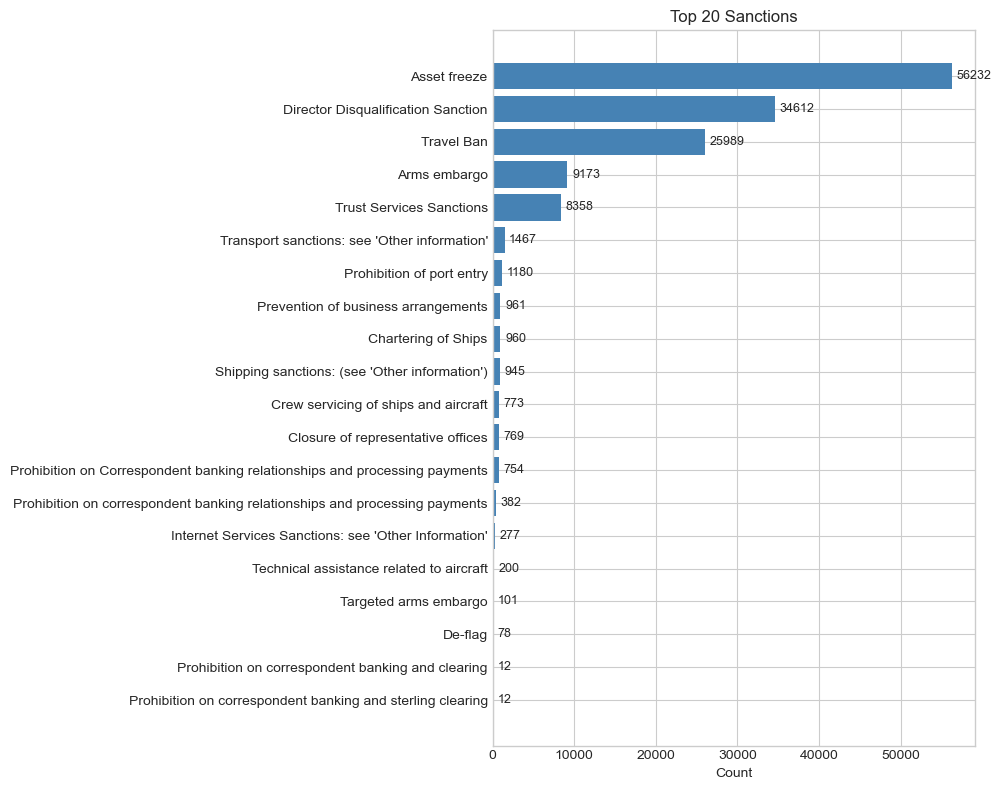

In [282]:
# Top-20 Sanctions Bar Chart
s = exploded_sanctions(df_copy['Sanctions Imposed']) if 'Sanctions Imposed' in df_copy.columns else pd.Series(dtype='object')
top = s.value_counts().head(20)
plt.figure(figsize=(10,8))
bars = plt.barh(top.index[::-1], top.values[::-1], color='steelblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + max(top.values) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{int(width)}', va='center', ha='left', fontsize=9)

plt.title('Top 20 Sanctions')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

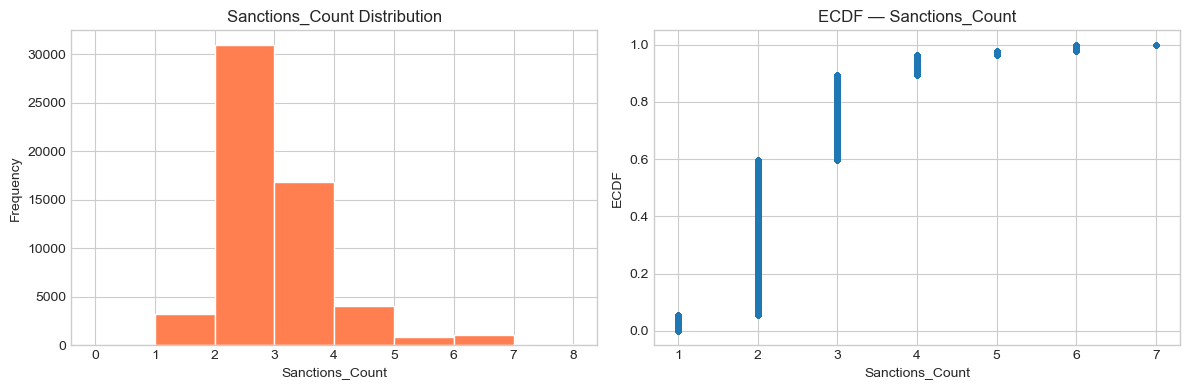

In [283]:
#Sanctions Count Histogram + ECDF
if 'Sanctions_Count' not in df_copy.columns:
    print('Sanctions_Count missing')
else:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    axes[0].hist(df_copy['Sanctions_Count'].dropna(), bins=range(0, int(df_copy['Sanctions_Count'].max())+2), color='coral', edgecolor='white')
    axes[0].set_title('Sanctions_Count Distribution')
    axes[0].set_xlabel('Sanctions_Count')
    axes[0].set_ylabel('Frequency')
    
    x = np.sort(df_copy['Sanctions_Count'].dropna())
    y = np.arange(1, len(x)+1) / len(x)
    axes[1].plot(x, y, marker='.', linestyle='none')
    axes[1].set_title('ECDF — Sanctions_Count')
    axes[1].set_xlabel('Sanctions_Count')
    axes[1].set_ylabel('ECDF')
    plt.tight_layout()
    plt.show()

In [284]:
# Choropleth by Country (Plotly)
try:
    import plotly.express as px
    PLOTLY = True  # Define PLOTLY variable to indicate Plotly is available
except ImportError:
    PLOTLY = False  # Set to False if Plotly import fails

if not PLOTLY:
    print('Plotly not available — run: pip install plotly')
else:
    country_col = 'Address Country' if 'Address Country' in df_copy.columns else None
    if country_col is None:
        print('Address Country column not found')
    else:
        counts = df_copy[country_col].fillna('Unknown').value_counts().reset_index()
        counts.columns = ['country','count']
        fig = px.choropleth(counts, locations='country', locationmode='country names', color='count',
                            color_continuous_scale='Blues', title='Counts by Country')
        fig.update_layout(margin=dict(l=10,r=10,t=40,b=10))
        fig.write_html('choropleth_country.html')
        print('✓ Choropleth saved to: choropleth_country.html')

✓ Choropleth saved to: choropleth_country.html


C:\Users\Nikhi\AppData\Local\Temp\ipykernel_23428\2180152339.py:17: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [285]:
#Treemap — Country to Sanction (Plotly)
if not PLOTLY:
    print('Plotly not available — run: pip install plotly')
else:
    if 'Sanctions Imposed' not in df_copy.columns or 'Address Country' not in df_copy.columns:
        print('Required columns missing')
    else:
        exploded = df_copy[['Address Country','Sanctions Imposed']].dropna()
        exploded = exploded.assign(Sanction=exploded['Sanctions Imposed'].str.split('|')).explode('Sanction')
        exploded['Sanction'] = exploded['Sanction'].str.strip()
        agg = exploded.groupby(['Address Country','Sanction']).size().reset_index(name='count')
        agg = agg.sort_values('count', ascending=False).head(200)
        fig = px.treemap(agg, path=['Address Country','Sanction'], values='count', title='Treemap: Country -> Sanction')
        fig.write_html('treemap_country_sanction.html')
        print('✓ Treemap saved to: treemap_country_sanction.html')

✓ Treemap saved to: treemap_country_sanction.html


# Data Quality Issues and Observations

The notebook reveals several data quality issues in the UK Sanctions List dataset:

- Missing values are present across multiple columns, and some fields are entirely empty. One example is `Hull identification number (HIN)`, which was dropped because it contained no useful data.
- Several fields are inconsistent in format or casing. Text values such as names, gender, and ship type required trimming and title-casing to make values consistent.
- Date fields appear in mixed or incomplete formats. `D.O.B` includes placeholder-style values such as `dd/mm/yyyy`, so these rows need special handling before conversion.
- Some columns contain compound values that needed parsing. Examples include `Sanctions Imposed` using `|` as a separator, `Designation source` containing multiple sources, and `Subsidiaries` containing concatenated company entries.
- `Phone number` values contain symbols and formatting noise, and `National Identifier number` values may include leading quotes or trailing `.0` artifacts.
- Duplicate records are present and were investigated using exact-row duplication checks. This suggests the dataset contains repeated entries that should be reviewed before downstream analysis.
